# **REPLICACION CODIGO DEL BLOG**

In [ ]:
pip install -U imbalanced-learn

**Análisis exploratorio, para comprobar el desequilibrio entre las clases**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

from pylab import rcParams

from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedBaggingClassifier

from collections import Counter

In [ ]:
df = pd.read_csv("creditcard.csv") # read in data downloaded to the local directory
df.head(n=5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df.shape)
print(pd.value_counts(df['Class'], sort = True))

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


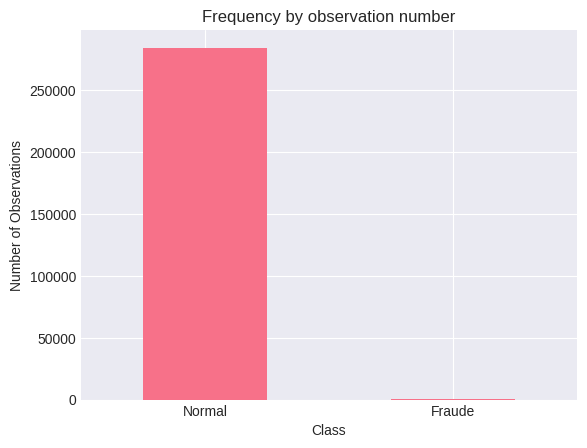

In [ ]:
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.xticks(range(2), LABELS)
plt.title("Frequency by observation number")
plt.xlabel("Class")
plt.ylabel("Number of Observations");

**Probando el Modelo “a secas” -sin estrategias-**

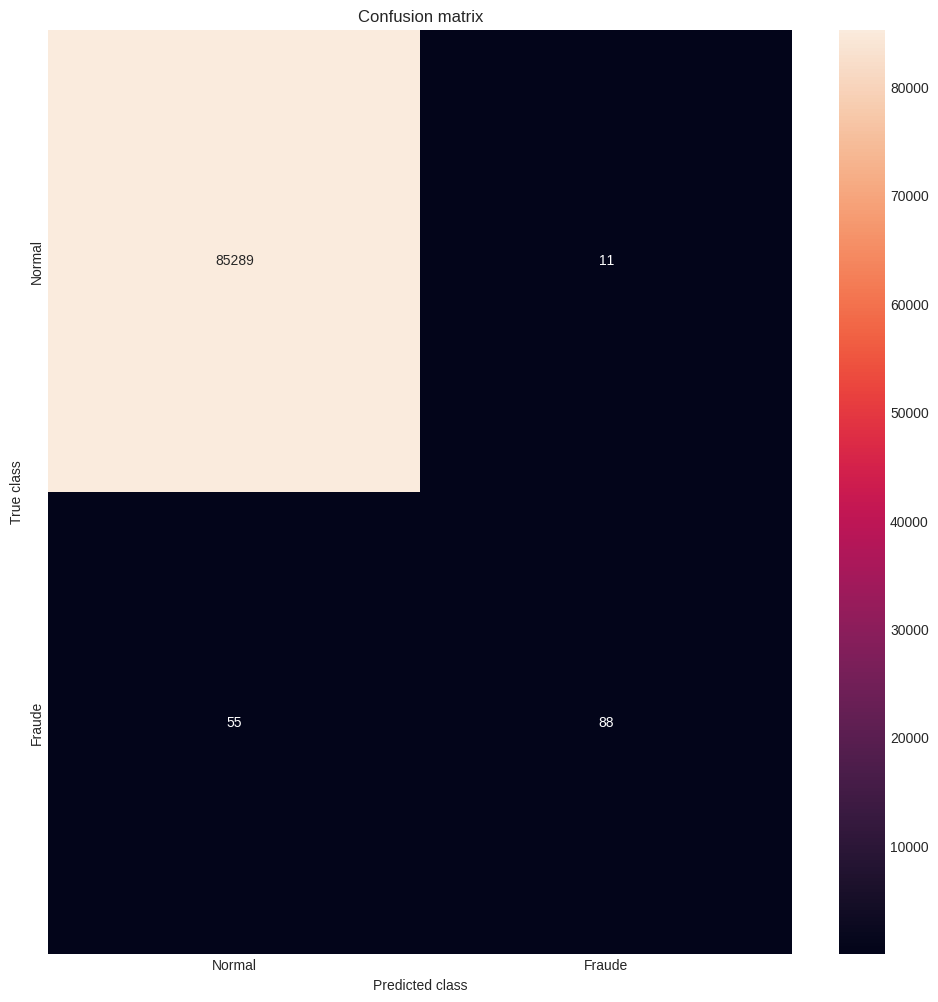

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85300
           1       0.89      0.62      0.73       143

    accuracy                           1.00     85443
   macro avg       0.94      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
#definimos nuestras etiquetas y features
y = df['Class']
X = df.drop('Class', axis=1)
#dividimos en sets de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

#creamos una función que crea el modelo que usaremos cada vez
def run_model(X_train, X_test, y_train, y_test):
    clf_base = LogisticRegression(C=1.0,penalty='l2',random_state=1,solver="newton-cg")
    clf_base.fit(X_train, y_train)
    return clf_base

#ejecutamos el modelo "tal cual"
model = run_model(X_train, X_test, y_train, y_test)

#definimos funciona para mostrar los resultados
def mostrar_resultados(y_test, pred_y):
    conf_matrix = confusion_matrix(y_test, pred_y)
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()
    print (classification_report(y_test, pred_y))

pred_y = model.predict(X_test)
mostrar_resultados(y_test, pred_y)

**Estrategia: Penalización para compensar**

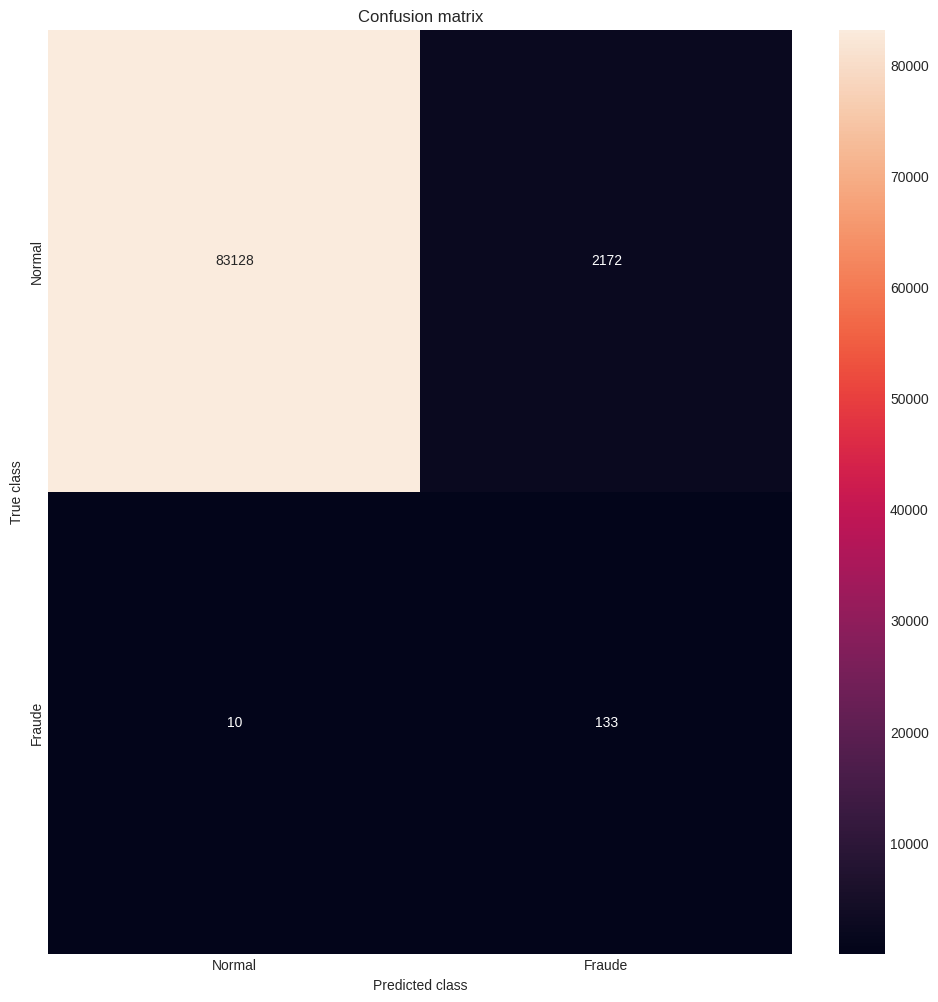

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     85300
           1       0.06      0.93      0.11       143

    accuracy                           0.97     85443
   macro avg       0.53      0.95      0.55     85443
weighted avg       1.00      0.97      0.99     85443



In [ ]:
def run_model_balanced(X_train, X_test, y_train, y_test):
    clf = LogisticRegression(C=1.0,penalty='l2',random_state=1,solver="newton-cg",class_weight="balanced")
    clf.fit(X_train, y_train)
    return clf

model = run_model_balanced(X_train, X_test, y_train, y_test)
pred_y = model.predict(X_test)
mostrar_resultados(y_test, pred_y)

**Estrategia: Subsampling en la clase mayoritaria**

Distribution before resampling Counter({0: 199015, 1: 349})
Distribution after resampling Counter({0: 698, 1: 349})


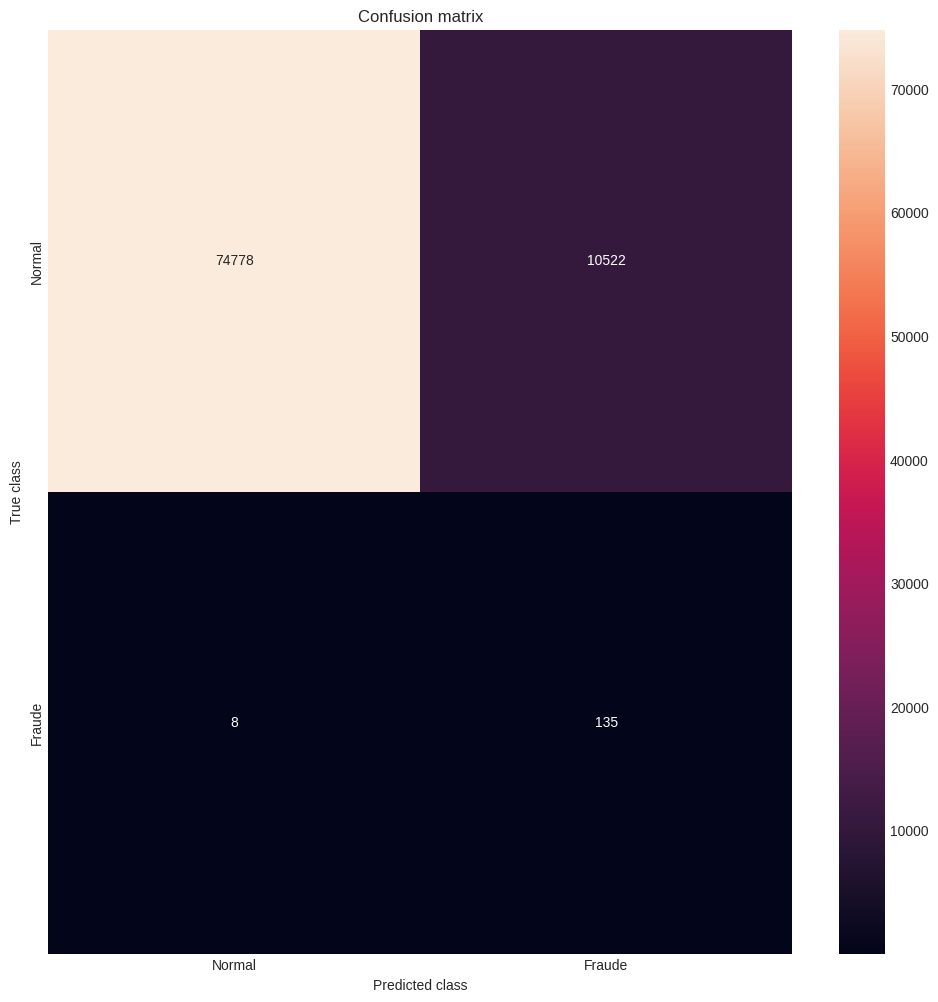

              precision    recall  f1-score   support

           0       1.00      0.88      0.93     85300
           1       0.01      0.94      0.03       143

    accuracy                           0.88     85443
   macro avg       0.51      0.91      0.48     85443
weighted avg       1.00      0.88      0.93     85443



In [ ]:
from imblearn.under_sampling import NearMiss
from collections import Counter

# Use correct parameter name based on your imbalanced-learn version
us = NearMiss(sampling_strategy=0.5, n_neighbors=3, version=2)  # Remove random_state
X_train_res, y_train_res = us.fit_resample(X_train, y_train)  # Changed from fit_sample to fit_resample

print("Distribution before resampling {}".format(Counter(y_train)))
print("Distribution after resampling {}".format(Counter(y_train_res)))

model = run_model(X_train_res, X_test, y_train_res, y_test)
pred_y = model.predict(X_test)
mostrar_resultados(y_test, pred_y)

**Estrategia: Oversampling de la clase minoritaria**

Distribution before resampling Counter({0: 199015, 1: 349})
Distribution labels after resampling Counter({0: 199015, 1: 99507})


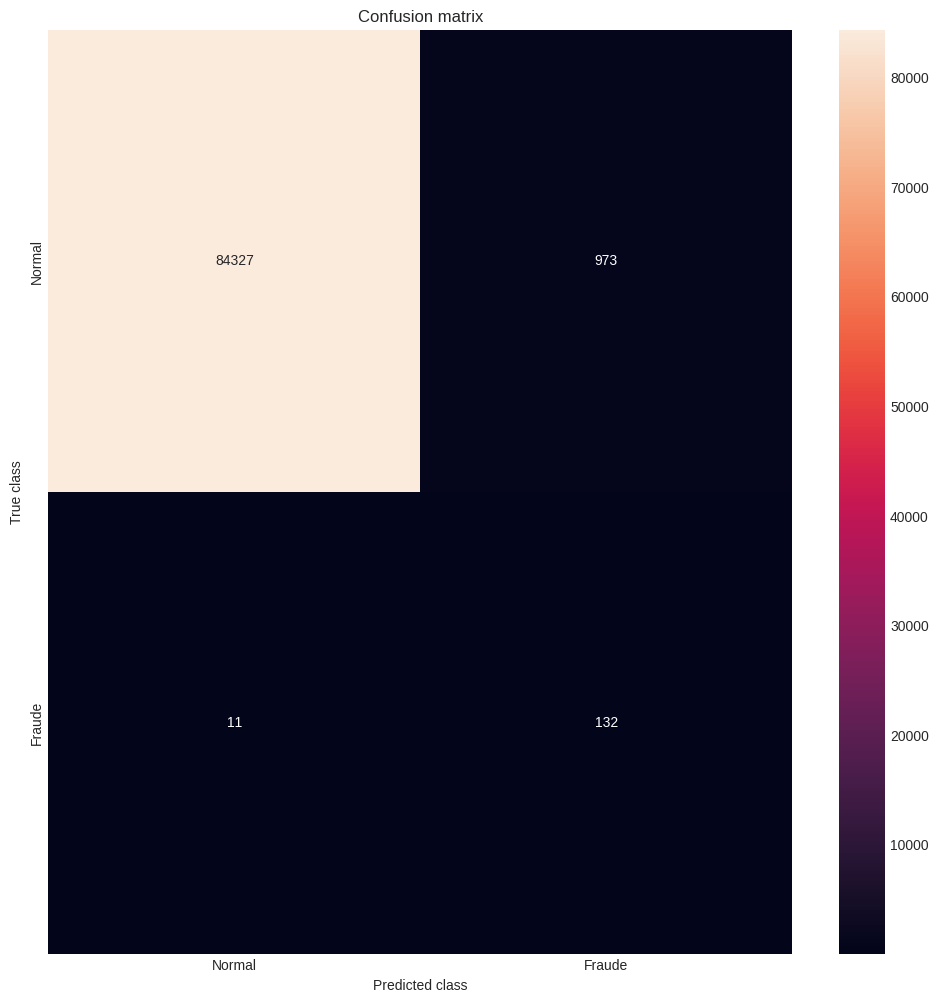

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     85300
           1       0.12      0.92      0.21       143

    accuracy                           0.99     85443
   macro avg       0.56      0.96      0.60     85443
weighted avg       1.00      0.99      0.99     85443



In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Use sampling_strategy instead of ratio
os = RandomOverSampler(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = os.fit_resample(X_train, y_train)  # Use fit_resample instead of fit_sample

print("Distribution before resampling {}".format(Counter(y_train)))
print("Distribution labels after resampling {}".format(Counter(y_train_res)))

model = run_model(X_train_res, X_test, y_train_res, y_test)
pred_y = model.predict(X_test)
mostrar_resultados(y_test, pred_y)

**Estrategia: Combinamos resampling con Smote-Tomek**

In [ ]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head(), df.shape


(   Time        V1        V2        V3        V4        V5        V6        V7  \
 0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
 1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
 2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
 3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
 4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
 
          V8        V9  ...       V21       V22       V23       V24       V25  \
 0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
 1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
 2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
 3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
 4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   
 
         V26      

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from collections import Counter

# train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Before splitting:", Counter(y))
print("Train distribution:", Counter(y_train))


Before splitting: Counter({0: 284315, 1: 492})
Train distribution: Counter({0: 227451, 1: 394})


In [ ]:
os_us = SMOTETomek(
    sampling_strategy=0.5,
    random_state=42
)

X_train_res, y_train_res = os_us.fit_resample(X_train, y_train)

print("After resampling:", Counter(y_train_res))


In [ ]:
model = run_model(X_train_res, X_test, y_train_res, y_test)
pred_y = model.predict(X_test)
mostrar_resultados(y_test, pred_y)

**Estrategia: Ensamble de Modelos con Balanceo**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedBaggingClassifier


In [ ]:
df = pd.read_csv("creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    sampling_strategy='auto',
    replacement=False,
    random_state=42,
    n_estimators=50
)

bbc.fit(X_train, y_train)
pred_y = bbc.predict(X_test)
mostrar_resultados(y_test, pred_y)
